<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/ArbolDecisionE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [36]:
data={
    'Sueño':[
        'Poco','Poco','Poco','Suficiente',
        'Suficiente','Suficiente','Poco','Suficiente'
    ],
    'Ejercicio':[
        'No','No','Sí','No',
        'Sí','Sí','Sí','No'
    ],
    'Carga_tarea':[
        'Alta','Normal','Alta','Alta',
        'Normal','Alta','Normal','Normal'
    ],
    'Estres':[
        'Sí','Sí','Sí','Sí',
        'No','No','No','No'
    ]
}
df=pd.DataFrame(data)
df

,Sueño,Ejercicio,Carga_tarea,Estres
0,Poco,No,Alta,Sí
1,Poco,No,Normal,Sí
2,Poco,Sí,Alta,Sí
3,Suficiente,No,Alta,Sí
4,Suficiente,Sí,Normal,No
5,Suficiente,Sí,Alta,No
6,Poco,Sí,Normal,No
7,Suficiente,No,Normal,No


In [37]:
le = LabelEncoder()
df_encoded = df.copy()
encoders = {}
for columna in ["Sueño", "Ejercicio", "Carga_tarea", "Estres"]:
    encoders[columna] = LabelEncoder()
    df_encoded[columna] = encoders[columna].fit_transform(df[columna])

df_encoded

,Sueño,Ejercicio,Carga_tarea,Estres
0,0,0,0,1
1,0,0,1,1
2,0,1,0,1
3,1,0,0,1
4,1,1,1,0
5,1,1,0,0
6,0,1,1,0
7,1,0,1,0


In [38]:
atributos = ["Sueño", "Ejercicio", "Carga_tarea"]
X = df_encoded[atributos]
y = df_encoded["Estres"]
modelo = DecisionTreeClassifier(
    criterion="entropy",    # Usa entropía como ID3
    random_state=42
)
modelo.fit(X, y)
print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de hojas:       {modelo.get_n_leaves()}")

Profundidad del árbol: 3
Número de hojas:       6


In [39]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=atributos
).sort_values(ascending=False)
for atributo, valor in importancias.items():
    print(f"  {atributo}: {valor:.4f}")
print()

  Sueño: 0.5000
  Carga_tarea: 0.3113
  Ejercicio: 0.1887



In [40]:
print("\nNodo raíz:")
importancias.index[0]


Nodo raíz:


'Sueño'

Text(0.5, 1.0, 'Árbol de Decisión ID3 (Entropía) - Diagnóstico de Estres')

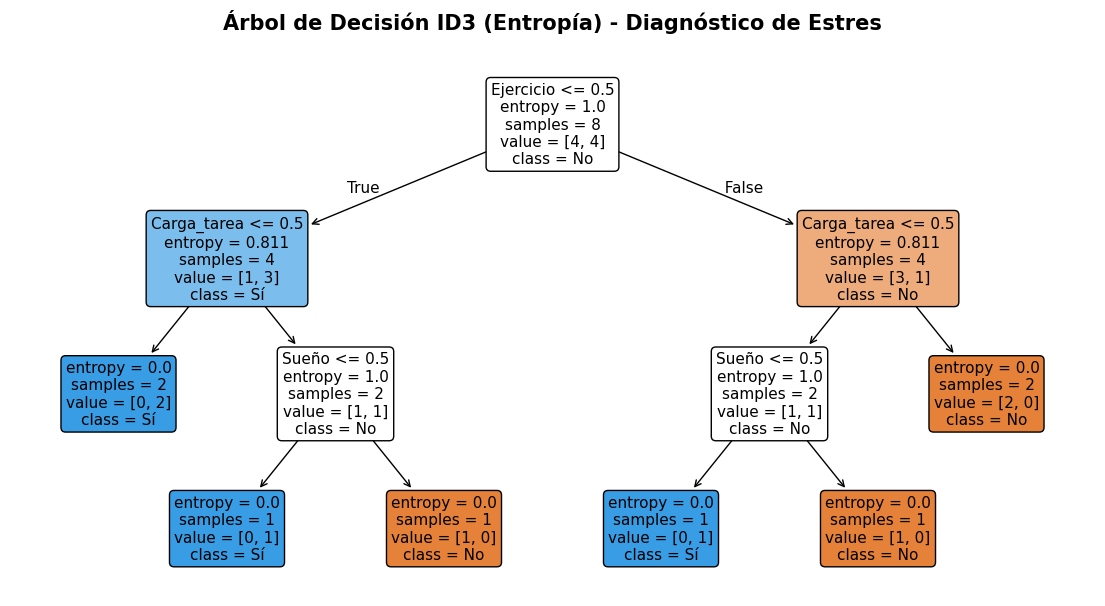

In [41]:
fig1, ax1 = plt.subplots(figsize=(14, 7))
plot_tree(
    modelo,
    feature_names=atributos,
    class_names=encoders["Estres"].classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax1,
    impurity=True,
    proportion=False
)
ax1.set_title(
    "Árbol de Decisión ID3 (Entropía) - Diagnóstico de Estres",
    fontsize=15,
    fontweight="bold",
    pad=20
)

**Predecir: ¿Un estudiante con Sueño=Poco, Ejercicio=No, Carga=Alta tiene estrés?**

In [42]:
nuevo = pd.DataFrame({
    "Sueño": ["Poco"],
    "Ejercicio": ["No"],
    "Carga_tarea": ["Alta"]
})
for col in nuevo.columns:
    nuevo[col] = encoders[col].transform(nuevo[col])
pred = modelo.predict(nuevo)
print("\nPredicción:")
print("Estrés =", encoders["Estres"].inverse_transform(pred)[0])


Predicción:
Estrés = Sí
